In [29]:
import numpy as numpy
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
# Load dữ liệu giá vàng Việt Nam từ file CSV 
df = pd.read_csv('../data/vietnam-gold-price.csv')


# Chuyển cột Date sang kiểu datetime và đặt làm index
df['Date'] = pd.to_datetime(df['Date'])

# Chuyển từng title của cột thành chữ thường và thay thế khoảng trắng bằng dấu gạch dưới
df.columns = df.columns.str.lower().str.replace(' ', '_')

 # Đặt cột date làm index để thuận tiện cho việc phân tích theo thời gian
df.set_index('date', inplace=True)
df.head()


,buy_price,sell_price
date,,
2009-08-01,21130000,21190000
2009-08-02,21130000,21190000
2009-08-03,21130000,21190000
2009-08-04,21130000,21190000
2009-08-05,21130000,21190000


In [30]:
# Sắp xếp theo thời gian tăng dần
df = df.sort_index(ascending=True)
print(f"Dữ liệu gồm {df.shape[0]} hàng và {df.shape[1]} cột")
df.head()

Dữ liệu gồm 5787 hàng và 2 cột


,buy_price,sell_price
date,,
2009-08-01,21130000,21190000
2009-08-02,21130000,21190000
2009-08-03,21130000,21190000
2009-08-04,21130000,21190000
2009-08-05,21130000,21190000


In [31]:
start_year = df.index.min().year
end_year = df.index.max().year
print(f"Dữ liệu từ năm {start_year} đến năm {end_year}") 

# Kiểm tra chi tiết từng năm
yearly_stats = df.groupby(df.index.year).size().reset_index(name='count')
print(yearly_stats)


Dữ liệu từ năm 2009 đến năm 2026
    date  count
0   2009    128
1   2010    365
2   2011    365
3   2012    366
4   2013    365
5   2014    365
6   2015    322
7   2016    312
8   2017    363
9   2018    222
10  2019    365
11  2020    366
12  2021    365
13  2022    365
14  2023    365
15  2024    366
16  2025    365
17  2026     57


In [32]:
print("Tóm tắt thống kê dữ liệu giá vàng Việt Nam:")
print(df.describe())

# Kiểm tra giá trị thiếu để đảm bảo dữ liệu sạch sẽ trước khi phân tích
print("Kiểm tra giá trị thiếu") 
print(df.isnull().sum())


Tóm tắt thống kê dữ liệu giá vàng Việt Nam:
          buy_price    sell_price
count  5.787000e+03  5.787000e+03
mean   5.191556e+07  5.248554e+07
std    2.636829e+07  2.698187e+07
min    2.113000e+07  2.119000e+07
25%    3.625000e+07  3.635000e+07
50%    4.165000e+07  4.190000e+07
75%    6.480000e+07  6.600000e+07
max    1.883000e+08  1.913000e+08
Kiểm tra giá trị thiếu
buy_price     0
sell_price    0
dtype: int64


PHÂN B - EDA TRỰC QUAN

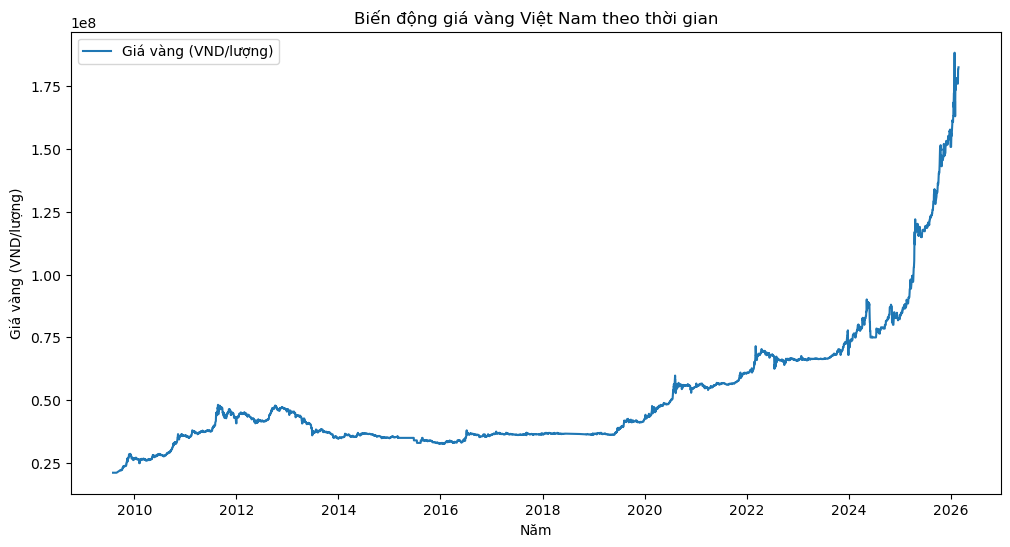

In [33]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['buy_price'], label='Giá vàng (VND/lượng)')
plt.title('Biến động giá vàng Việt Nam theo thời gian')
plt.xlabel('Năm')
plt.ylabel('Giá vàng (VND/lượng)')
plt.legend()
plt.show()

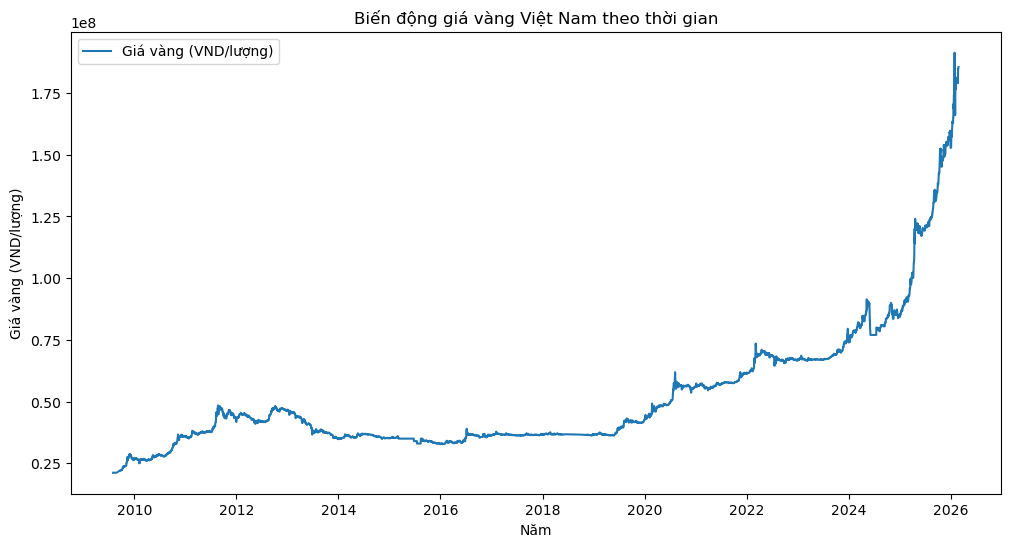

In [34]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['sell_price'], label='Giá vàng (VND/lượng)')
plt.title('Biến động giá vàng Việt Nam theo thời gian')
plt.xlabel('Năm')
plt.ylabel('Giá vàng (VND/lượng)')
plt.legend()
plt.show()

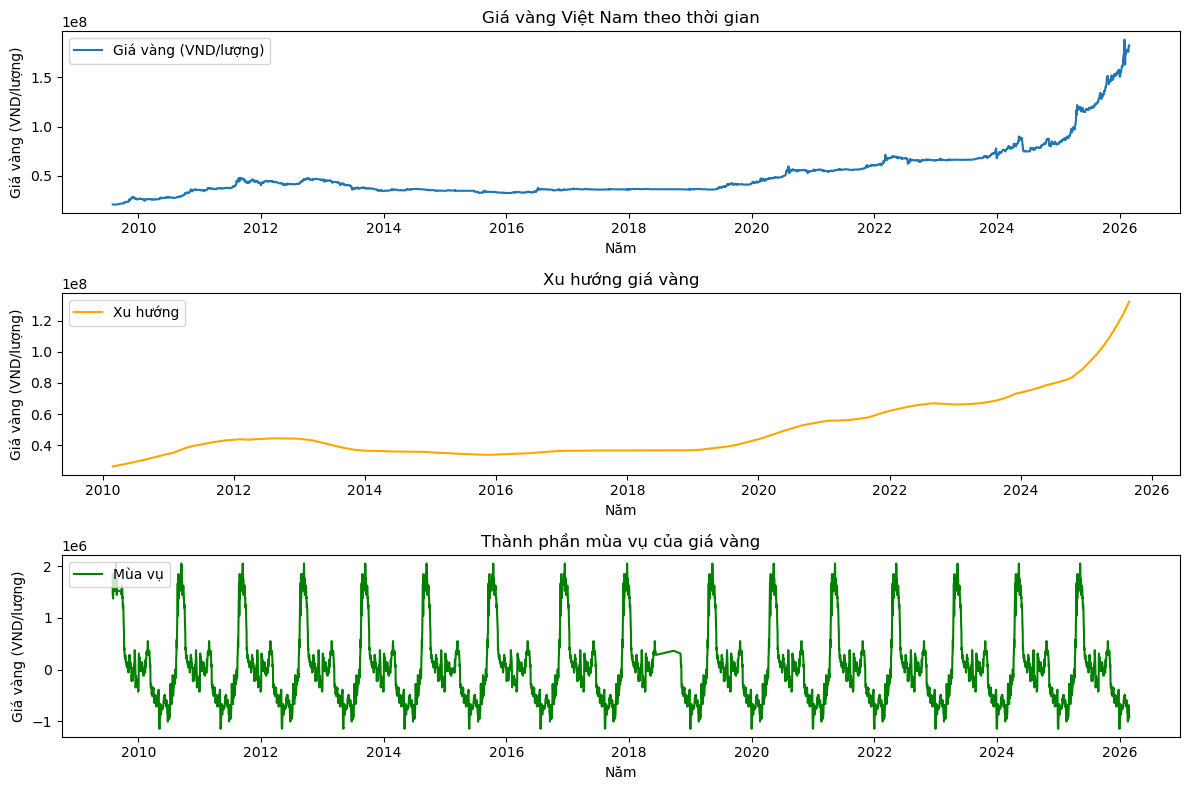

In [35]:
import matplotlib.dates as mdates
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.seasonal import seasonal_decompose
# Phân tích thành phần mùa vụ để hiểu rõ hơn về xu hướng và mùa vụ
decomposition = seasonal_decompose(df['buy_price'], model='additive', period=365)
trend = decomposition.trend
seasonal = decomposition.seasonal
plt.figure(figsize=(12, 8))
plt.subplot(3, 1, 1)
plt.plot(df.index, df['buy_price'], label='Giá vàng (VND/lượng)')
plt.title('Giá vàng Việt Nam theo thời gian')
plt.xlabel('Năm')
plt.ylabel('Giá vàng (VND/lượng)')
plt.legend()
plt.subplot(3, 1, 2)
plt.plot(df.index, trend, label='Xu hướng', color='orange')
plt.title('Xu hướng giá vàng')
plt.xlabel('Năm')
plt.ylabel('Giá vàng (VND/lượng)')
plt.legend()
plt.subplot(3, 1, 3)
plt.plot(df.index, seasonal, label='Mùa vụ', color='green')
plt.title('Thành phần mùa vụ của giá vàng')
plt.xlabel('Năm')
plt.ylabel('Giá vàng (VND/lượng)')
plt.legend()
plt.tight_layout()
plt.show()


In [39]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import pandas as pd

train = df['buy_price'][:int(0.8*len(df))]
test = df['buy_price'][int(0.8*len(df)):]
# Huấn luyện mô hình ARIMA
model = ARIMA(train, order=(5, 1, 0))  # Tham số (p, d, q) có thể được điều chỉnh
model_fit = model.fit()

# Dự báo giá vàng trong tập kiểm tra
predictions = model_fit.forecast(steps=len(test))

# Đánh giá mô hình bằng cách tính MSE
mse = mean_squared_error(test, predictions)
print(mse)

e:\Downloads\New folder\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
e:\Downloads\New folder\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
e:\Downloads\New folder\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


1659012843102614.0


e:\Downloads\New folder\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
e:\Downloads\New folder\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
